In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import shap
from lime.lime_tabular import LimeTabularExplainer

In [31]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Admin\OneDrive\task 3
['dataset.csv', 'fairness_analysis.ipynb', 'report.txt']


In [32]:
with open("dataset.csv", "r", encoding="utf-8") as f:
    print(f.read())

age,gender,income,education,loan_status
21,M,20000,10,0
25,F,30000,12,1
28,M,35000,12,0
32,F,40000,14,1
35,M,50000,16,0
40,F,60000,16,1
45,M,70000,18,0
50,F,80000,18,1
23,F,25000,12,1
30,M,45000,14,0



In [33]:
print("Hello - Notebook is working")

Hello - Notebook is working


In [34]:
f = open("dataset.csv", "r", encoding="utf-8")
content = f.read()
f.close()

print(content)


age,gender,income,education,loan_status
21,M,20000,10,0
25,F,30000,12,1
28,M,35000,12,0
32,F,40000,14,1
35,M,50000,16,0
40,F,60000,16,1
45,M,70000,18,0
50,F,80000,18,1
23,F,25000,12,1
30,M,45000,14,0



In [35]:
import pandas as pd

data = {
    "age": [21, 25, 28, 32, 35, 40, 45, 50, 23, 30],
    "gender": ["M", "F", "M", "F", "M", "F", "M", "F", "F", "M"],
    "income": [20000, 30000, 35000, 40000, 50000, 60000, 70000, 80000, 25000, 45000],
    "education": [10, 12, 12, 14, 16, 16, 18, 18, 12, 14],
    "loan_status": [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

df.to_csv(r"C:\Users\Admin\OneDrive\task 3\dataset.csv", index=False)

print("Dataset created successfully")

Dataset created successfully


In [36]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\OneDrive\task 3\dataset.csv")
df.head()

,age,gender,income,education,loan_status
0,21,M,20000,10,0
1,25,F,30000,12,1
2,28,M,35000,12,0
3,32,F,40000,14,1
4,35,M,50000,16,0


In [37]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [38]:
X["gender"] = X["gender"].map({"M": 0, "F": 1})

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [40]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


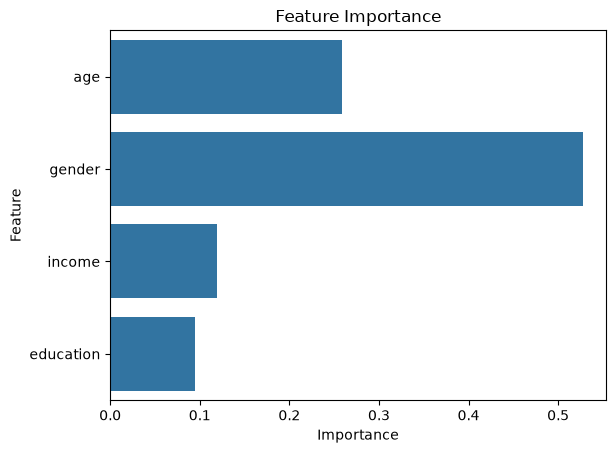

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

feat = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

sns.barplot(data=feat, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

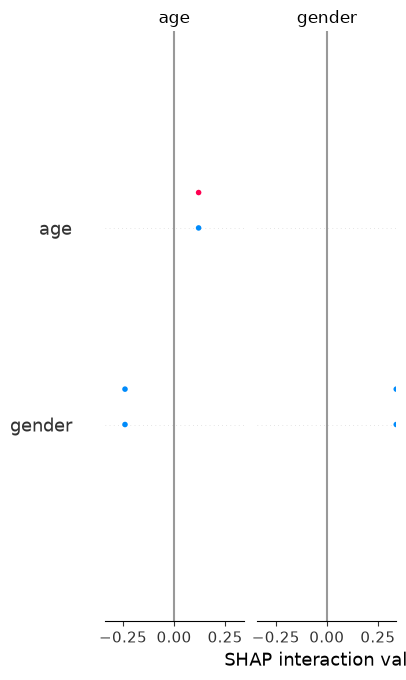

In [42]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [43]:
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["pred"] = y_pred

# Add gender back for fairness check
test_df["gender"] = X_test["gender"]

group_accuracy = test_df.groupby("gender").apply(
    lambda x: (x["actual"] == x["pred"]).mean()
)

print(group_accuracy)

gender
1    1.0
dtype: float64


In [44]:
gap = group_accuracy.max() - group_accuracy.min()
print("Fairness Gap:", gap)

Fairness Gap: 0.0


In [45]:
from sklearn.ensemble import RandomForestClassifier
import pickle

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# SAVE MODEL
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("model.pkl created successfully")

model.pkl created successfully


In [46]:
import os
print(os.listdir())

['app.py', 'dataset.csv', 'fairness_analysis.ipynb', 'model.pkl', 'report.txt']


In [47]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [50]:
print(type(X_test))
print(X_test.shape)

<class 'pandas.DataFrame'>
(2, 4)


In [51]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [53]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

In [54]:
print(shap_values.values.shape)

(2, 4, 2)


In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\Admin\OneDrive\task 3\dataset.csv")
df.columns = df.columns.str.strip()

df["gender"] = LabelEncoder().fit_transform(df["gender"])

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [60]:
# if binary classification → take class 1 only
values = shap_values.values

if len(values.shape) == 3:
    values = values[:, :, 1]   # take positive class

importance = np.abs(values).mean(axis=0)

In [61]:
# if binary classification → take class 1 only
values = shap_values.values

if len(values.shape) == 3:
    values = values[:, :, 1]   # take positive class

importance = np.abs(values).mean(axis=0)

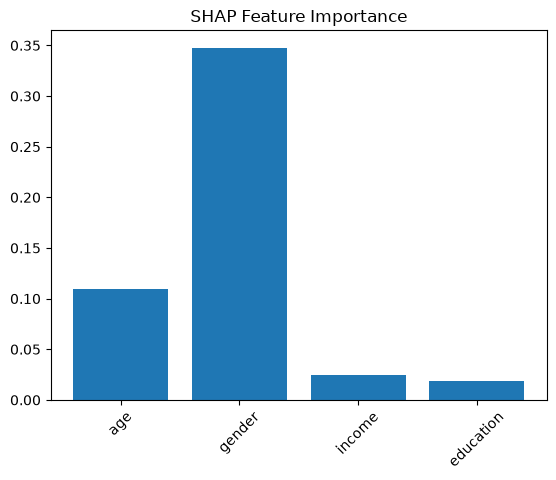

In [62]:
plt.bar(X_test.columns, importance)
plt.xticks(rotation=45)
plt.title("SHAP Feature Importance")
plt.show()

In [64]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [66]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_np = X_train.values
X_test_np = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=X_train.columns,
    class_names=["Rejected", "Approved"],
    mode="classification"
)

i = 0
exp = explainer.explain_instance(
    X_test_np[i],
    model.predict_proba
)

# SAFE OUTPUT (NO NOTEBOOK ERROR)
print(exp.as_list())

[('gender <= 0.00', 0.5971088745033821), ('age <= 29.50', -0.11468013444153863), ('education <= 13.50', -0.023264900846271384), ('income <= 38750.00', -0.018419135083400283)]


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
